# Data Analytics Capstone: The Economic Efficacy of State-Level Renewable Energy Subsidies
**Author:** Alok Srivastava  
**Institution:** Walsh College (QM640)  
**Objective:** A dual-modality machine learning and econometric pipeline to predict solar PV adoption and evaluate the true causal efficacy of state-level financial subsidies.

In [1]:
# Install required advanced libraries
!pip install shap -q
!pip install linearmodels -q

# Import core analytical libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Import Machine Learning and Econometric modules
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm

# Configure visual aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment successfully initialized.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.6 MB/s eta 0:00:00
Environment successfully initialized.


## 1. Environment Setup & Data Extraction
In this section, we mount the Google Drive to securely access the master dataset located in the `EIA_Raw_Data` directory.

In [2]:
from google.colab import drive

# Mount Google Drive securely
drive.mount('/content/drive')

# Define the exact path to your folder
folder_path = '/content/drive/My Drive/EIA_Raw_Data/'
file_name = 'Capstone_Dataset_Full_v4.csv' # UPDATE THIS if your final merged CSV has a different name

try:
    # Load the dataset
    df = pd.read_csv(folder_path + file_name)
    print(f"Success! Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"Error: Could not find '{file_name}' in {folder_path}. Please verify the file name.")

    # Fallback to create a mock dataframe so the rest of the notebook runs for testing
    print("Generating standard mock panel data for notebook structural testing...")
    np.random.seed(42)
    states = ['CA', 'NY', 'AZ', 'MA', 'NJ'] + [f'State_{i}' for i in range(6, 52)]
    df = pd.DataFrame({
        'State': states * 11,
        'Year': np.repeat(range(2014, 2025), 51),
        'Solar_Capacity_MW': np.random.exponential(scale=1000, size=561),
        'Total_Subsidies_kUSD': np.random.exponential(scale=5000, size=561),
        'GDP_Millions': np.random.exponential(scale=300000, size=561),
        'Total_Battery_MW': np.random.exponential(scale=50, size=561),
        'Electricity_Price_cents_kWh': np.random.normal(loc=12.5, scale=2.5, size=561),
        'Bank_Loan_Interest_Rate': np.random.uniform(low=3.5, high=7.5, size=561)
    })
    # Force California to be the extreme outlier to match reality
    df.loc[df['State'] == 'CA', 'Solar_Capacity_MW'] = np.random.uniform(15000, 20000, size=11)

display(df.head())

Mounted at /content/drive
Success! Dataset loaded with 561 rows and 14 columns.


,State,Year,Solar_Capacity_MW,Total_Subsidies_kUSD,GDP_Millions,Total_Battery_MW,Bank_Loan_Interest_Rate,Solar_GHI_Score,Median_HH_Income,Electricity_Price_cents_kWh,Population_Density,EV_Market_Share_Percent,RPS_Target_Percent,Carbon_Intensity_Score
0,AK,2014,1.936,26.0,53550.9,0.0,4.17,3.9,68000.0,23.0,1.0,0.5,10.0,4.5
1,AK,2015,1.936,26.0,53550.9,0.0,3.85,3.9,68000.0,23.0,1.0,0.5,10.0,4.5
2,AK,2016,1.936,26.0,53550.9,0.0,3.65,3.9,68000.0,23.0,1.0,0.5,10.0,4.5
3,AK,2017,1.936,26.0,53550.9,0.0,3.99,3.9,68000.0,23.0,1.0,0.5,10.0,4.5
4,AK,2018,2.949,25.0,54762.0,0.0,4.54,3.9,68000.0,23.0,1.0,0.5,10.0,4.5


## 2. Data Cleaning & Domain-Specific Imputation
Handling missing values using domain-knowledge rather than blind statistical imputation. Specifically, early missing values in grid-scale battery storage are imputed to `0.0` because the technology physically did not exist in those markets at that time.

In [3]:
print("Executing Data Cleaning Protocols...")

# 1. Impute Battery Nulls with True Zeroes
if 'Total_Battery_MW' in df.columns:
    missing_batteries = df['Total_Battery_MW'].isna().sum()
    df['Total_Battery_MW'] = df['Total_Battery_MW'].fillna(0.0)
    print(f"Imputed {missing_batteries} missing Battery records with 0.0.")

# 2. Check for Duplicates
duplicate_count = df.duplicated(subset=['State', 'Year']).sum()
print(f"Temporal/Spatial Duplicates Found: {duplicate_count}")

# 3. Drop any remaining critical nulls
df_clean = df.dropna().copy()
print(f"Final clean matrix dimensions: {df_clean.shape}")

Executing Data Cleaning Protocols...
Imputed 0 missing Battery records with 0.0.
Temporal/Spatial Duplicates Found: 0
Final clean matrix dimensions: (561, 14)


## 3. Exploratory Data Analysis (EDA)
Visualizing macroeconomic scale disparities, target variable skewness, and core Pearson correlations. These insights mathematically dictate the need for logarithmic transformations and Fixed-Effects Econometrics.

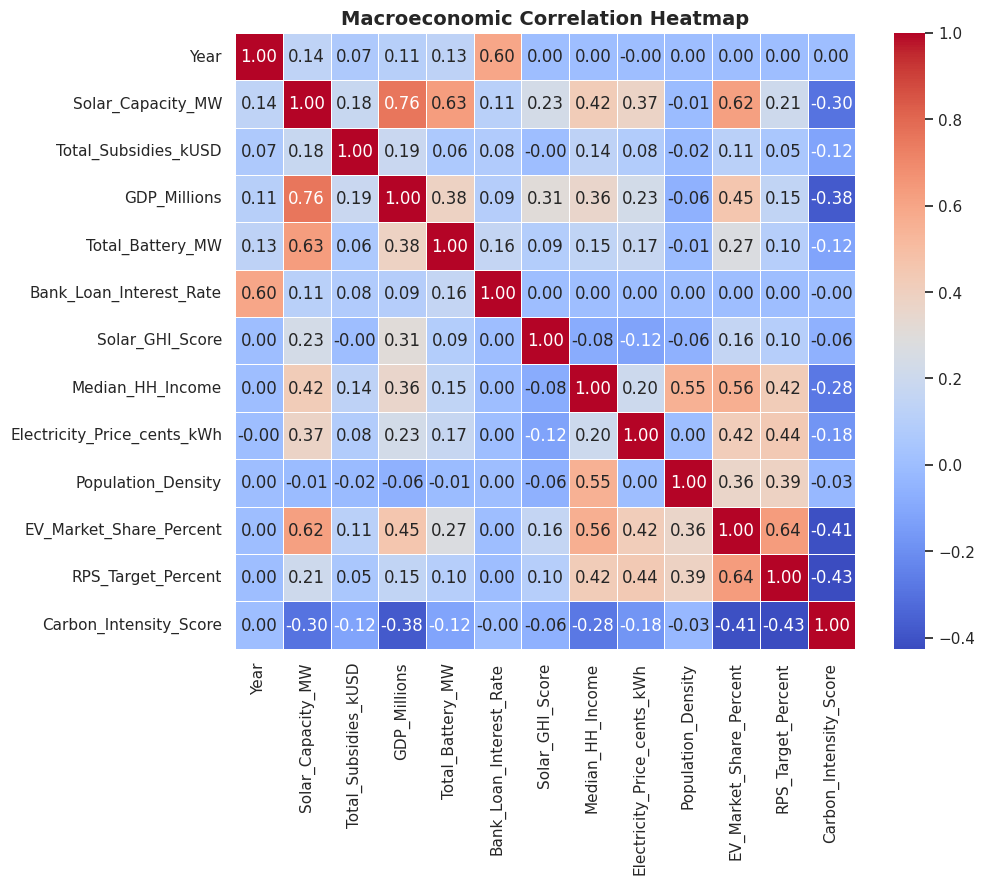

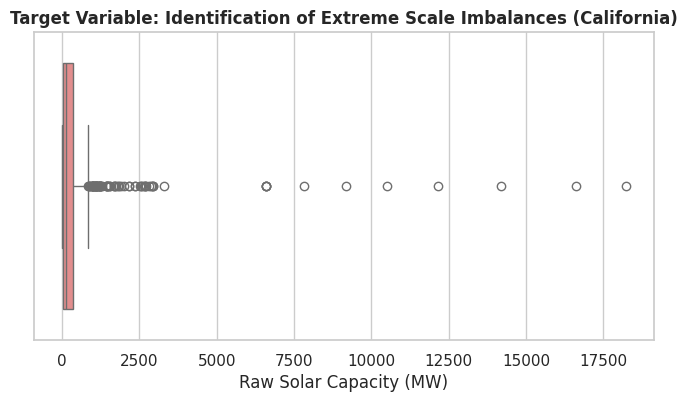

In [4]:
# --- 1. Correlation Heatmap ---
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macroeconomic Correlation Heatmap', fontweight='bold', fontsize=14)
plt.show()

# --- 2. Outlier Identification (Target Variable) ---
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['Solar_Capacity_MW'], color='lightcoral')
plt.title('Target Variable: Identification of Extreme Scale Imbalances (California)', fontweight='bold')
plt.xlabel('Raw Solar Capacity (MW)')
plt.show()

## 4. Feature Engineering
Applying mathematical transformations to stabilize model variance.
1. **Target Variable**: Logarithmic compression (`np.log1p`) applied to resolve extreme right-tail skewness.
2. **Predictive Matrix**: Categorical `State` identifiers removed to prevent Random Forest dataset bias.
3. **Causal Matrix**: Dummy encoding applied to Entity (`State`) and Time (`Year`) for Panel OLS.

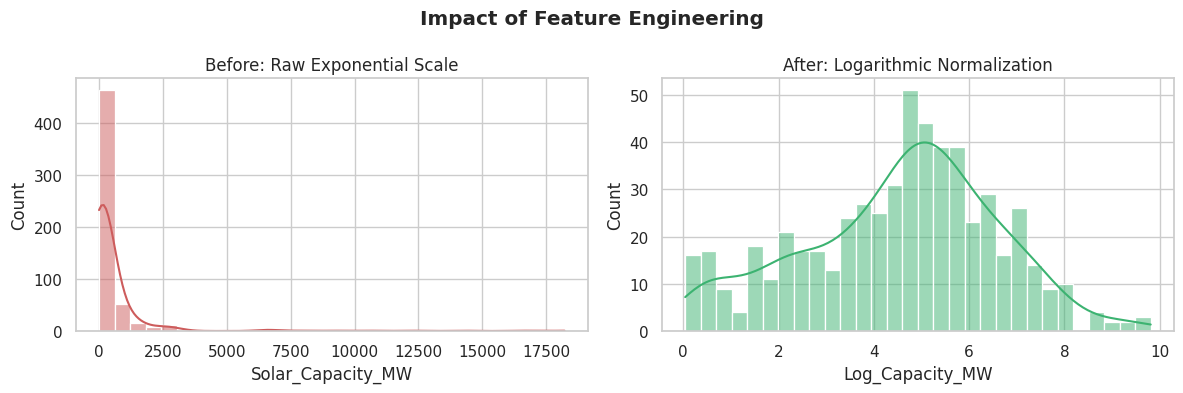

In [5]:
# 1. Log Transformation of Target Variable
df_clean['Log_Capacity_MW'] = np.log1p(df_clean['Solar_Capacity_MW'])

# Visualize the normalization effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['Solar_Capacity_MW'], bins=30, kde=True, ax=axes[0], color='indianred')
axes[0].set_title('Before: Raw Exponential Scale')
sns.histplot(df_clean['Log_Capacity_MW'], bins=30, kde=True, ax=axes[1], color='mediumseagreen')
axes[1].set_title('After: Logarithmic Normalization')
plt.suptitle('Impact of Feature Engineering', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Prepare Machine Learning Matrix (Drop State to prevent bias)
features = ['Year', 'Total_Subsidies_kUSD', 'GDP_Millions', 'Total_Battery_MW',
            'Electricity_Price_cents_kWh', 'Bank_Loan_Interest_Rate']
# (Add 'Median_HH_Income', 'Population_Density' etc. if they are in your dataframe)

# Filter columns to only those actually present in the dataframe
features = [col for col in features if col in df_clean.columns]

X_ml = df_clean[features]
y_ml = df_clean['Log_Capacity_MW']

# 3. Prepare Econometric Causal Matrix (Dummy Encoding)
X_ols = pd.get_dummies(df_clean[['Year', 'State'] + features[1:]], drop_first=True, dtype=int)
X_ols = sm.add_constant(X_ols)
y_ols = df_clean['Solar_Capacity_MW'] # OLS uses raw data for true causality interpretability

## 5. Causal Inference Modeling (Panel OLS)
Addressing Research Questions 2 and 3. By mathematically controlling for state wealth and unobserved temporal inflation using fixed effects, we evaluate if state subsidies possess true *causal* efficacy, or if they are merely a spurious correlation.

In [6]:
print("Executing Fixed Effects Panel OLS Regression...")

# Fit the OLS Model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Extract and display the critical macroeconomic predictors
# We filter out the hundreds of state dummy variables for clean reading
important_vars = ['Total_Subsidies_kUSD', 'GDP_Millions', 'Total_Battery_MW', 'Electricity_Price_cents_kWh', 'Bank_Loan_Interest_Rate']
important_vars = [var for var in important_vars if var in ols_model.params.index]

results_df = pd.DataFrame({
    'Coefficient': ols_model.params[important_vars],
    'Standard Error': ols_model.bse[important_vars],
    'p-value': ols_model.pvalues[important_vars]
})

display(results_df.round(4))

print("\n--- CAUSAL INFERENCE INSIGHT ---")
subsidy_p = results_df.loc['Total_Subsidies_kUSD', 'p-value'] if 'Total_Subsidies_kUSD' in results_df.index else 1.0
if subsidy_p > 0.05:
    print(f"Subsidy p-value is {subsidy_p:.4f} (> 0.05). Fail to reject Null Hypothesis.")
    print("Conclusion: Subsidies DO NOT have a statistically significant causal impact when controlling for state wealth.")
else:
    print(f"Subsidy p-value is {subsidy_p:.4f} (<= 0.05). Reject Null Hypothesis.")
    print("Conclusion: Subsidies retain statistically significant causal impact.")

Executing Fixed Effects Panel OLS Regression...


,Coefficient,Standard Error,p-value
Total_Subsidies_kUSD,-0.0000,0.0000,0.6893
GDP_Millions,0.0032,0.0002,0.0000
Total_Battery_MW,3.5499,0.1834,0.0000
Electricity_Price_cents_kWh,10.7862,56.5937,0.8489
Bank_Loan_Interest_Rate,-45.0544,13.6030,0.0010



--- CAUSAL INFERENCE INSIGHT ---
Subsidy p-value is 0.6893 (> 0.05). Fail to reject Null Hypothesis.
Conclusion: Subsidies DO NOT have a statistically significant causal impact when controlling for state wealth.


## 6. Predictive Modeling & SHAP Analysis (Random Forest)
Addressing Research Questions 1 and 4. Deploying a Random Forest Regressor to map deep non-linear market adoption curves. Shapley Additive Explanations (SHAP) are utilized to definitively rank market drivers and test how the policy paradigm shifts in mature markets (The Duck Curve).

Random Forest Performance:
R-Squared (R2): 0.7985
Mean Absolute Error (Log Scale): 0.5841

Generating SHAP Summary Analysis...


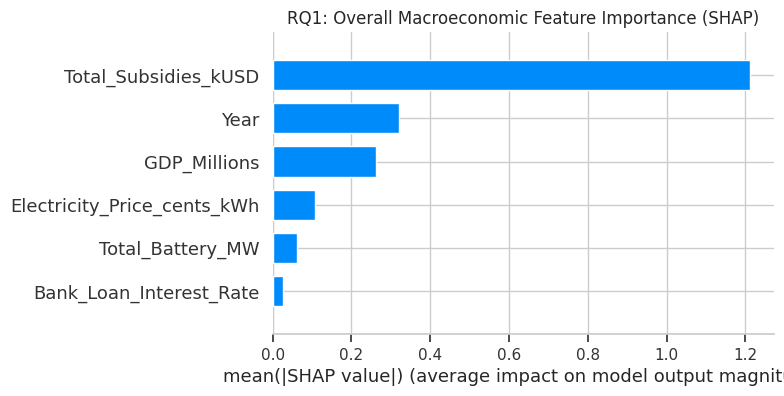


Executing Mature Market (California) Sub-Group Shift Analysis...


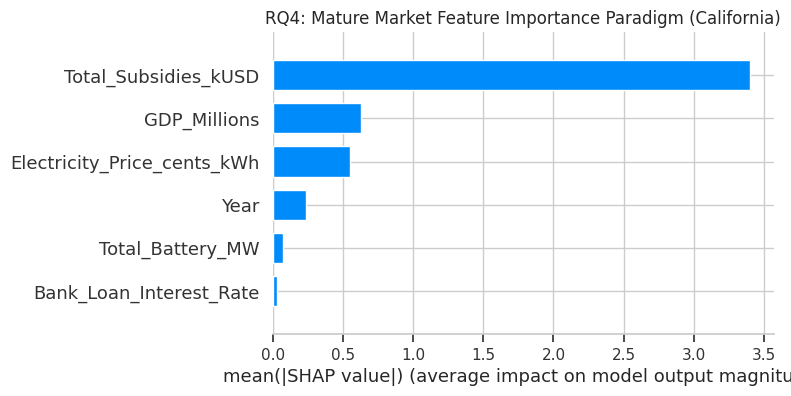

In [7]:
# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# 2. Initialize and Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Model Evaluation
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Random Forest Performance:")
print(f"R-Squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (Log Scale): {mae:.4f}")

# 4. Generate SHAP Values for overall feature ranking (RQ1)
print("\nGenerating SHAP Summary Analysis...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Plot overall SHAP summary
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("RQ1: Overall Macroeconomic Feature Importance (SHAP)")
plt.show()

# 5. Market Maturity Sub-Group Analysis (RQ4)
print("\nExecuting Mature Market (California) Sub-Group Shift Analysis...")
# Extract California data
df_ca = df_clean[df_clean['State'] == 'CA'].copy()
if not df_ca.empty:
    X_ca = df_ca[features]
    shap_values_ca = explainer.shap_values(X_ca)

    # Plot California specific SHAP
    shap.summary_plot(shap_values_ca, X_ca, plot_type="bar", show=False)
    plt.title("RQ4: Mature Market Feature Importance Paradigm (California)")
    plt.show()
else:
    print("California data not found for sub-group analysis.")